Accuracy: 0.6934
Macro F1: 0.6805

Classification Report:
                                                                            precision    recall  f1-score   support

                                                       Akarna_Dhanurasana       0.60      0.55      0.57        11
                              Bharadvajas_Twist_pose_or_Bharadvajasana_I_       0.50      0.42      0.45        12
                                         Boat_Pose_or_Paripurna_Navasana_       0.69      0.83      0.75        24
                                     Bound_Angle_Pose_or_Baddha_Konasana_       0.86      0.43      0.57        28
                                                 Bow_Pose_or_Dhanurasana_       0.72      0.69      0.71        26
                                 Bridge_Pose_or_Setu_Bandha_Sarvangasana_       0.85      0.63      0.72        27
                                                 Camel_Pose_or_Ustrasana_       0.69      0.77      0.73        26
                    

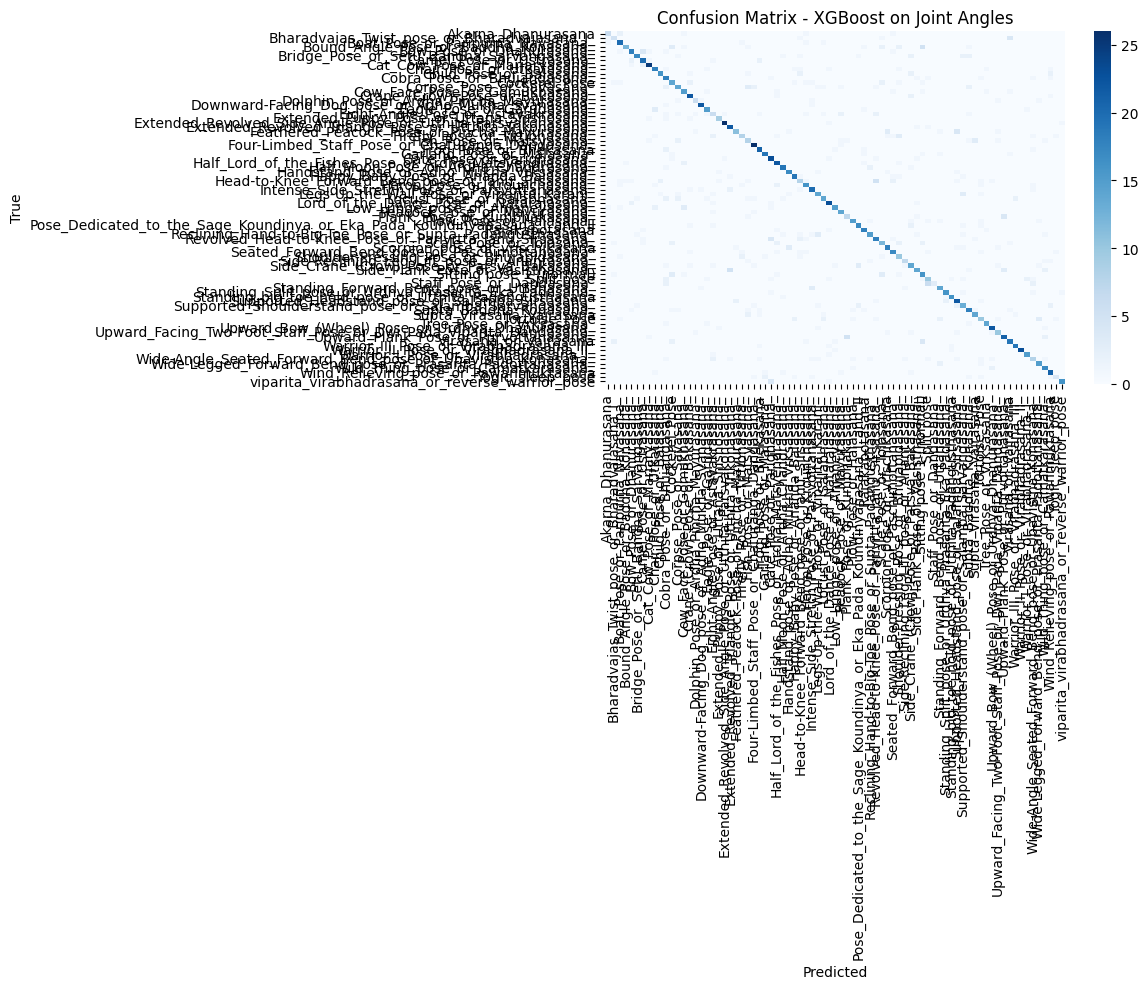

In [4]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib

# --- Load processed train/test ---
PROC_DIR = Path("../data/processed")
train_file = PROC_DIR / "processed_train.npz"
test_file = PROC_DIR / "processed_test.npz"

train_npz = np.load(train_file, allow_pickle=True)
test_npz = np.load(test_file, allow_pickle=True)

X_train, y_train = train_npz["angles"], train_npz["labels"]
X_test, y_test = test_npz["angles"], test_npz["labels"]

# Encode labels (string -> int)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# --- Train XGBoost ---
model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train_enc)

# --- Evaluation ---
y_pred = model.predict(X_test)

acc = accuracy_score(y_test_enc, y_pred)
f1 = f1_score(y_test_enc, y_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred, target_names=le.classes_))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test_enc, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - XGBoost on Joint Angles")
plt.tight_layout()
plt.show()




In [5]:
# --- Save model + encoder ---
joblib.dump(model, "../models/xgboost_angles.pkl")
joblib.dump(le, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']


=== Training XGBoost ===
XGBoost Accuracy: 0.6934, Macro F1: 0.6805, Training time: 25.10s

=== Training RandomForest ===
RandomForest Accuracy: 0.7212, Macro F1: 0.7103, Training time: 2.12s

=== Training LogisticRegression ===


c:\Users\Harsh\.conda\envs\joint_classi\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression Accuracy: 0.4810, Macro F1: 0.4456, Training time: 11.65s

=== Model Comparison ===
                Model  Accuracy  Macro F1  Train Time (s)
0             XGBoost  0.693356  0.680543       25.097659
1        RandomForest  0.721181  0.710342        2.117861
2  LogisticRegression  0.480977  0.445633       11.651182


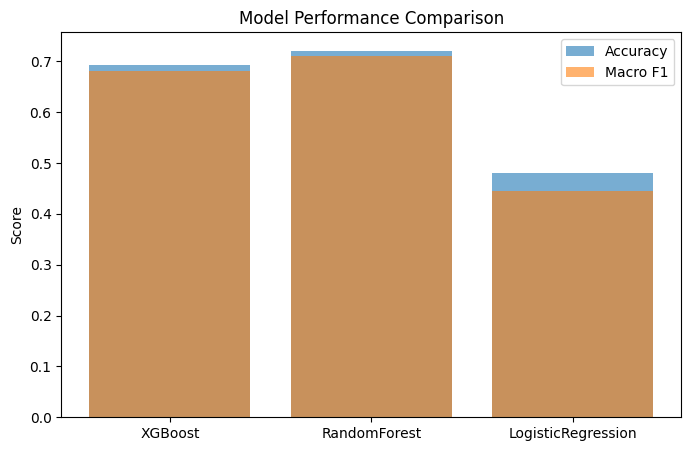

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from pathlib import Path

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# --- Load dataset ---
PROC_DIR = Path("../data/processed")
train_file = PROC_DIR / "processed_train.npz"
test_file = PROC_DIR / "processed_test.npz"

train_npz = np.load(train_file, allow_pickle=True)
test_npz = np.load(test_file, allow_pickle=True)

X_train, y_train = train_npz["angles"], train_npz["labels"]
X_test, y_test = test_npz["angles"], test_npz["labels"]

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# --- Model configs ---
models = {
    "XGBoost": xgb.XGBClassifier(
        objective="multi:softmax",
        num_class=len(le.classes_),
        eval_metric="mlogloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=500,
        multi_class="multinomial",
        solver="lbfgs",
        n_jobs=-1
    )
}

results = []

# --- Train + Evaluate each model ---
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    start = time.time()
    model.fit(X_train, y_train_enc)
    end = time.time()
    train_time = end - start
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_enc, y_pred)
    f1 = f1_score(y_test_enc, y_pred, average="macro")
    
    print(f"{name} Accuracy: {acc:.4f}, Macro F1: {f1:.4f}, Training time: {train_time:.2f}s")
    results.append({"Model": name, "Accuracy": acc, "Macro F1": f1, "Train Time (s)": train_time})
    
    # Save model
    joblib.dump(model, f"../models/{name.lower()}_angles.pkl")

# --- Results Table ---
df_results = pd.DataFrame(results)
print("\n=== Model Comparison ===")
print(df_results)

# --- Plot Comparison ---
plt.figure(figsize=(8,5))
plt.bar(df_results["Model"], df_results["Accuracy"], alpha=0.6, label="Accuracy")
plt.bar(df_results["Model"], df_results["Macro F1"], alpha=0.6, label="Macro F1")
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()
